In [1]:
import scanpy as sc

adata=sc.read_h5ad('beta_T2D.h5ad')
adata

AnnData object with n_obs × n_vars = 99029 × 26936
    obs: 'Clusters', 'LibraryID', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'BMI', 'HbA1c', 'Islet', 'Center', 'Medication', 'Viability', 'Purity', 'Cause_of_death', 'Multiplex', 'BMI_Category', 'Clusters_DiseaseState', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'is_primary_data', 'Viability_2', 'Purity_2', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'cell_type_ontology_term_id_colors', 'citation', 'or

In [2]:
# 假设你的数据是 adata
# 1. 标记线粒体基因 (通常以 'MT-' 开头)
adata.var['mt'] = adata.var_names.str.startswith('MT-') 

# 2. 计算 QC 指标
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# 3. 过滤细胞和基因
# 过滤掉检测到基因数少于 200 的细胞，以及在少于 3 个细胞中表达的基因
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# 4. 根据线粒体占比过滤 (通常阈值设为 5% 或 10%)
adata = adata[adata.obs.pct_counts_mt < 5, :]

print(f"QC 后的数据规模: {adata.n_obs} 细胞 x {adata.n_vars} 基因")

QC 后的数据规模: 99029 细胞 x 25125 基因


In [3]:
# 备份原始计数数据（可选，用于某些后期分析）
adata.layers["counts"] = adata.X.copy()

# 1. 标准化：使每个细胞的总计数达到 10,000
sc.pp.normalize_total(adata, target_sum=1e4)

# 2. 对数转换：将数据转换为 log(x+1)
sc.pp.log1p(adata)

/tmp/ipykernel_3508879/1206044331.py:2: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers["counts"] = adata.X.copy()


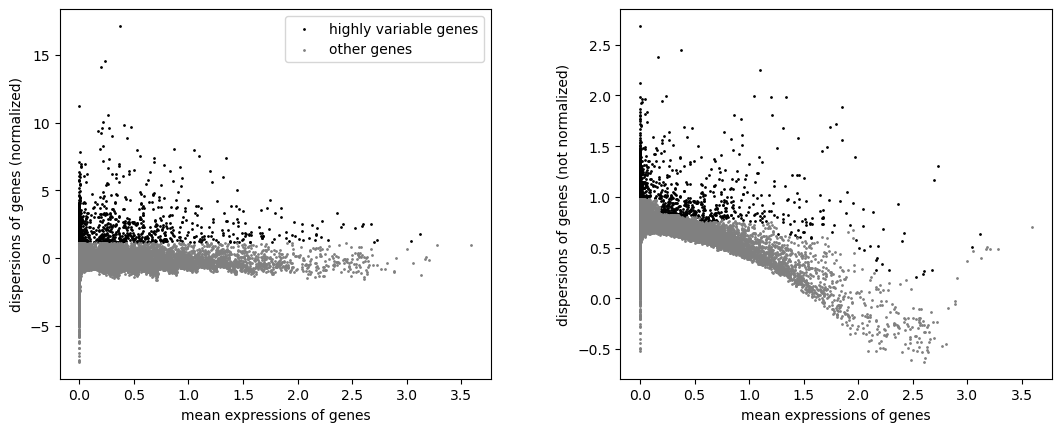

In [8]:
# 筛选高变基因
# batch_key 参数可选，如果你的数据包含多个样本，建议填入 batch 字段以减少批次效应影响
sc.pp.highly_variable_genes(adata,n_top_genes=2000)

# 绘制高变基因图表
sc.pl.highly_variable_genes(adata)

# 只保留高变基因（或者将其标记出来，在后续 PCA 中使用）
# adata = adata[:, adata.var.highly_variable] # 如果只想保留 HVG，取消此行注释

In [9]:
adata_hvg=adata[:,adata.var['highly_variable']]
adata_hvg

View of AnnData object with n_obs × n_vars = 99029 × 2000
    obs: 'Clusters', 'LibraryID', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'BMI', 'HbA1c', 'Islet', 'Center', 'Medication', 'Viability', 'Purity', 'Cause_of_death', 'Multiplex', 'BMI_Category', 'Clusters_DiseaseState', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'is_primary_data', 'Viability_2', 'Purity_2', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'fea

In [19]:
adata.obs['development_stage'].isin(['34-year-old stage','35-year-old stage','37-year-old stage','38-year-old stage'])

adata.obs['disease'].isin(['type 2 diabetes mellitus','normal']).sum()

index=(adata.obs['sex']=='female') & (adata.obs['disease'].isin(['type 2 diabetes mellitus','normal'])) & (adata.obs['development_stage'].isin(['34-year-old stage','35-year-old stage','37-year-old stage','38-year-old stage']))

index.sum()

9950

In [24]:
processed_adata=adata_hvg[index]
processed_adata.obs['cell_type']

processed_adata.write_h5ad('beta_T2D_processed.h5ad')

In [31]:
processed_adata.obs['cell_type']

MS17006_AAACCTGGTGCGAAAC    type B pancreatic cell
MS17006_AAACCTGTCAACGAAA    type B pancreatic cell
MS17006_AAACCTGTCGTGACAT    type B pancreatic cell
MS17006_AAACGGGGTTACTGAC    type B pancreatic cell
MS17006_AAAGATGGTTGTGGCC    type B pancreatic cell
                                     ...          
MS21001_TTTGGAGGTGGTCCCA    type B pancreatic cell
MS21001_TTTGGTTGTTTACGAC    type B pancreatic cell
MS21001_TTTGTTGAGAAATCCA    type B pancreatic cell
MS21001_TTTGTTGCAGCATACT    type B pancreatic cell
MS21001_TTTGTTGGTGACAACG    type B pancreatic cell
Name: cell_type, Length: 9950, dtype: category
Categories (1, object): ['type B pancreatic cell']

In [29]:
processed_adata.var['feature_name']

ENSG00000188290               HES4
ENSG00000187608              ISG15
ENSG00000179403               VWA1
ENSG00000187730              GABRD
ENSG00000149527              PLCH2
                        ...       
ENSG00000176302              FOXR1
ENSG00000287319    ENSG00000287319
ENSG00000213215              OR2F1
ENSG00000075886             TUBA3D
ENSG00000263970    ENSG00000263970
Name: feature_name, Length: 2000, dtype: category
Categories (1998, object): ['A1CF', 'ABCB5', 'ABCC8', 'ABCC9', ..., 'ZNF556', 'ZNF705EP', 'ZNF775-AS1', 'ZNF80']

In [1]:
import scanpy as sc

adata=sc.read_h5ad('beta_T2D_processed.h5ad')
adata

AnnData object with n_obs × n_vars = 9950 × 2000
    obs: 'Clusters', 'LibraryID', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'BMI', 'HbA1c', 'Islet', 'Center', 'Medication', 'Viability', 'Purity', 'Cause_of_death', 'Multiplex', 'BMI_Category', 'Clusters_DiseaseState', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'is_primary_data', 'Viability_2', 'Purity_2', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type

/tmp/ipykernel_3928759/3868908922.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, palette='Set3')


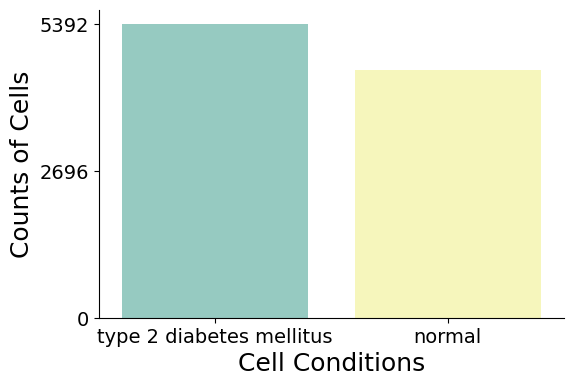

In [9]:

import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42
# Count the occurrences of each diabetes status
status_counts = adata.obs['disease'].value_counts()

# Create a bar plot
plt.figure(figsize=(6, 4))
sns.barplot(x=status_counts.index, y=status_counts.values, palette='Set3')
plt.xlabel('Cell Conditions', size=18)
plt.ylabel('Counts of Cells', size=18)
plt.yticks([0,max(status_counts.values)//2,max(status_counts.values)],size=14)
plt.xticks(size=14)
sns.despine()
plt.savefig("beta_T2D_disease_status_counts.pdf", bbox_inches="tight")
plt.show()